`WORLD_BANK DATA EXPLORATION`

IMPORT LIB

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os 
from pathlib import Path
from xgboost import XGBRegressor
import seaborn as sns 

`imf data`

In [60]:
def read_csv(df):
        BASE_DIR = Path.cwd().resolve().parent.parent
        RAW_PATH = BASE_DIR /"macro_data_project" / "include" / "pipeline" /"data" / "raw" / "imf"
        file_path = RAW_PATH / f"{df}"
        return pd.read_csv(file_path)
    
dfi=read_csv('data_imf.csv')

`world_bank data`

In [61]:
def read_csv(df):
        BASE_DIR = Path.cwd().resolve().parent.parent
        RAW_PATH = BASE_DIR /"macro_data_project" / "include" / "pipeline" /"data" / "raw" / "world_bank"
        file_path = RAW_PATH / f"{df}"
        return pd.read_csv(file_path)
    
dfw=read_csv('data_world_bank.csv')

In [62]:
dfw[dfw["Country"]=="Egypt"].head()

,Country,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate
1080,Egypt,1980,6.612494e+09,5.482857e+08,2.166991e+10,10.011329,493.053573,3.395570e+09,9.289543e+09,20.819225,5.959225e+09,55.673,43950413.0,43.887709
1081,Egypt,1981,6.853649e+09,7.525714e+08,2.213608e+10,7.348554,490.308797,3.838243e+09,9.628784e+09,10.317284,7.105405e+09,56.454,45147224.0,43.909559
1082,Egypt,1982,7.282512e+09,2.935714e+08,2.765517e+10,9.907171,595.918898,4.413916e+09,1.047266e+10,14.823009,8.006158e+09,57.219,46407611.0,43.928094
1083,Egypt,1983,7.101281e+09,4.900000e+08,3.096624e+10,5.094407,648.013630,4.889406e+09,1.059371e+10,16.079874,9.545984e+09,57.967,47786402.0,43.943148
1084,Egypt,1984,6.987745e+09,7.291429e+08,3.397119e+10,9.745763,689.807676,5.267684e+09,1.085788e+10,17.036366,1.032036e+10,58.697,49247334.0,43.954558


`merge`

In [63]:
dfi.rename(columns={
        "country": "Country",
        "year": "Year"
        }, inplace=True)
df_mg=dfw.merge(
            dfi,
            on=["Country", "Year"],
            how="inner"
        )

`Exploration`

In [64]:
df_mg.describe()

,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate,exchange_rate
count,4083.000000,3.785000e+03,4.041000e+03,4.026000e+03,4023.000000,4026.000000,3.714000e+03,3.785000e+03,3822.000000,3.796000e+03,4083.000000,4.083000e+03,4083.000000,4.083000e+03
mean,2002.733529,1.378200e+11,1.115934e+10,5.157009e+11,3.426724,14659.253507,8.953180e+10,1.351512e+11,27.590873,1.378482e+11,71.737675,6.095792e+07,63.818525,1.227914e+03
std,12.774474,3.121503e+11,4.131144e+10,1.800338e+12,5.181716,19441.189759,2.792108e+11,3.237842e+11,277.811354,5.150267e+11,8.211758,1.768325e+08,21.379970,3.344744e+04
min,1980.000000,6.932810e+05,-3.434028e+11,4.077963e+08,-64.047107,22.952133,4.180568e+07,1.849551e+06,-16.117326,-2.465806e+09,31.473000,2.281380e+05,10.374611,2.281232e-11
25%,1992.000000,9.137589e+09,1.632663e+08,2.430666e+10,1.484169,1886.658331,3.953467e+09,1.067030e+10,2.143757,6.128330e+09,67.939634,5.419040e+06,52.142234,1.000000e+00
50%,2003.000000,3.055936e+10,1.381200e+09,8.557119e+10,3.553063,6087.890790,1.341012e+10,3.148819e+10,4.611580,2.279016e+10,73.455000,1.531931e+07,67.669698,5.570083e+00
75%,2014.000000,1.158333e+11,6.498650e+09,3.031196e+11,5.678076,20641.118967,5.037570e+10,1.095323e+11,10.053567,7.705476e+10,77.420256,4.743794e+07,79.997381,5.467494e+01
max,2024.000000,3.753056e+12,7.338265e+11,2.875096e+13,82.809329,137781.681659,3.570077e+12,4.103100e+12,11749.639632,7.768897e+12,84.580488,1.450936e+09,100.000000,2.104581e+06


In [65]:
df_mg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4083 non-null   object 
 1   Year                       4083 non-null   int64  
 2   Exports                    3785 non-null   float64
 3   Foreign Direct Investment  4041 non-null   float64
 4   GDP                        4026 non-null   float64
 5   GDP Growth                 4023 non-null   float64
 6   GDP per Capita             4026 non-null   float64
 7   Government Spending        3714 non-null   float64
 8   Imports                    3785 non-null   float64
 9   Inflation Rate             3822 non-null   float64
 10  Investment                 3796 non-null   float64
 11  Life Expectancy            4083 non-null   float64
 12  Population                 4083 non-null   float64
 13  Unemployment Rate          4083 non-null   float

In [66]:
df_mg.isnull().sum() / 4320 

Country                      0.000000
Year                         0.000000
Exports                      0.068981
Foreign Direct Investment    0.009722
GDP                          0.013194
GDP Growth                   0.013889
GDP per Capita               0.013194
Government Spending          0.085417
Imports                      0.068981
Inflation Rate               0.060417
Investment                   0.066435
Life Expectancy              0.000000
Population                   0.000000
Unemployment Rate            0.000000
country_code                 0.000000
exchange_rate                0.000000
dtype: float64

`nulls`

In [67]:
data = pd.read_csv(r"D:\project\Data Science\macro_data_project\data\raw\data_after_clean_delete_null.csv")

In [68]:
data.isna().sum()

Country                      0
Year                         0
Exports                      0
Foreign Direct Investment    0
GDP                          0
GDP Growth                   0
GDP per Capita               0
Government Spending          0
Imports                      0
Inflation Rate               0
Investment                   0
Life Expectancy              0
Population                   0
Unemployment Rate            0
exchange_rate                0
dtype: int64

`Out liears`

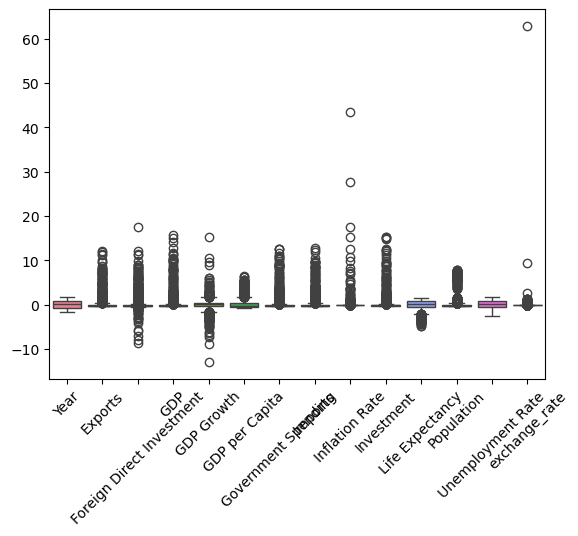

In [69]:
from sklearn.preprocessing import StandardScaler
num_cols = data.select_dtypes(include="number").columns
plt.Figure(figsize=(12,10))
scaler = StandardScaler()
scaled = scaler.fit_transform(data[num_cols])
scaled_df = pd.DataFrame(scaled, columns=num_cols)


sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)
plt.show()

c:\Users\Omar\anaconda3\envs\DL_Torch\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\Omar\anaconda3\envs\DL_Torch\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


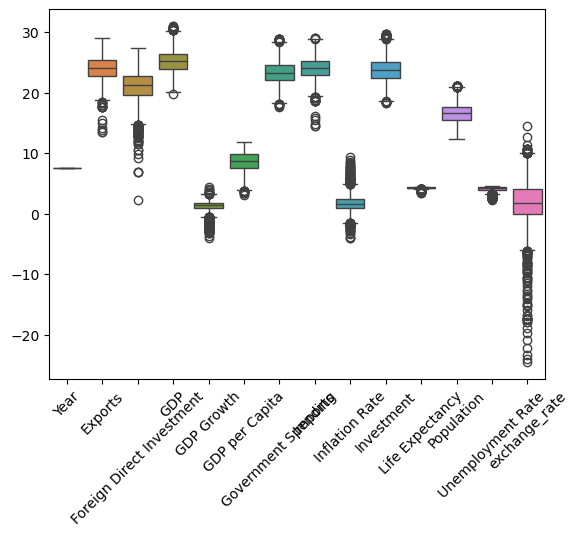

In [70]:
num_cols = data.select_dtypes(include="number").columns
plt.Figure(figsize=(12,10))
scaled = np.log(data[num_cols])

scaled_df = pd.DataFrame(scaled, columns=num_cols)

sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)
plt.show()

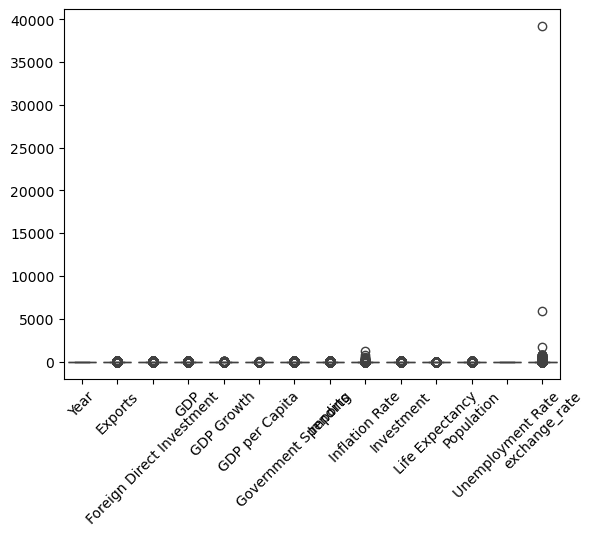

In [71]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled = scaler.fit_transform(data[num_cols])
scaled_df = pd.DataFrame(scaled, columns=num_cols)


sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)
plt.show()

In [72]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# num_cols = df.select_dtypes(include="number").columns

# plt.figure(figsize=(12,6))
# sns.boxplot(data=df[num_cols])

# plt.xticks(rotation=45)
# plt.show()

`FEATURE ENGINEERING`

`add economic Crisis`

In [73]:
def add_crisis_encode(df):
    df = df.copy()

    crisis_map = {
        "Financial_Crisis": (2008, 2009),
        "COVID_Crisis": (2020, 2021),
        "Energy_Crisis": (2022, 2023)
    }

    for name, (start, end) in crisis_map.items():
        df[name] = df["Year"].between(start, end).astype(int)

    return df


In [74]:
df=add_crisis_encode(data)

In [75]:
df['Total_Crisis'] = (
    df['Financial_Crisis'] +
    df['COVID_Crisis'] +
    df['Energy_Crisis']
)
df=df.drop(['Financial_Crisis',
    'COVID_Crisis',
    'Energy_Crisis'],axis=1)
df.columns

Index(['Country', 'Year', 'Exports', 'Foreign Direct Investment', 'GDP',
       'GDP Growth', 'GDP per Capita', 'Government Spending', 'Imports',
       'Inflation Rate', 'Investment', 'Life Expectancy', 'Population',
       'Unemployment Rate', 'exchange_rate', 'Total_Crisis'],
      dtype='object')

In [76]:
df = df.sort_values(['Country', 'Year'])

df['Trade_Balance'] = df['Exports'] - df['Imports']

df['Inflation_diff'] = df.groupby('Country')['Inflation Rate'].pct_change()
df['Unemployment_diff'] = df.groupby('Country')['Unemployment Rate'].pct_change()
df['GDP_growth_calc'] = df.groupby('Country')['GDP'].pct_change()
df['Population_growth'] = df.groupby('Country')['Population'].pct_change()
df['Investment_growth'] = df.groupby('Country')['Investment'].pct_change()

# this is improtant because it give us the retio 
df['Investment_to_GDP'] = df['Investment'] / df['GDP']
df['Trade_to_GDP'] = df['Trade_Balance'] / df['GDP']

#  Shock Features (Outliers Detection)
df['Inflation_MA3'] = df.groupby('Country')['Inflation Rate'].shift(1).rolling(3).mean()

df['Inflation_volatility'] = df.groupby('Country')['Inflation Rate'].shift(1).rolling(5).std()
df['Exchange_volatility'] = df.groupby('Country')['exchange_rate'].shift(1).rolling(5).std()

# The inflation in this year >? inflation to the last 5 years + upper threshold ----> detect the shocks that crisis make or other things
df['Inflation_shock'] = (df['Inflation Rate'] > df['Inflation Rate'].rolling(5).mean() + 2*df['Inflation Rate'].rolling(5).std()).astype(int)

In [77]:
df.isna().sum()

Country                        0
Year                           0
Exports                        0
Foreign Direct Investment      0
GDP                            0
GDP Growth                     0
GDP per Capita                 0
Government Spending            0
Imports                        0
Inflation Rate                 0
Investment                     0
Life Expectancy                0
Population                     0
Unemployment Rate              0
exchange_rate                  0
Total_Crisis                   0
Trade_Balance                  0
Inflation_diff                96
Unemployment_diff             96
GDP_growth_calc               96
Population_growth             96
Investment_growth            136
Investment_to_GDP              0
Trade_to_GDP                   0
Inflation_MA3                288
Inflation_volatility         480
Exchange_volatility          480
Inflation_shock                0
dtype: int64

In [78]:
df["Inflation_volatility"].unique()

array([       nan, 0.        , 2.63930803, ..., 0.70863989, 0.65634391,
       0.59740599])

In [79]:
print("Before:", df.shape)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print("After:", df.shape)

Before: (4083, 28)
After: (3569, 28)


In [80]:
train = df[df['Year'] <= 2015]
val   = df[(df['Year'] > 2015) & (df['Year'] <= 2018)]
test  = df[df['Year'] > 2018]

In [81]:
train.columns

Index(['Country', 'Year', 'Exports', 'Foreign Direct Investment', 'GDP',
       'GDP Growth', 'GDP per Capita', 'Government Spending', 'Imports',
       'Inflation Rate', 'Investment', 'Life Expectancy', 'Population',
       'Unemployment Rate', 'exchange_rate', 'Total_Crisis', 'Trade_Balance',
       'Inflation_diff', 'Unemployment_diff', 'GDP_growth_calc',
       'Population_growth', 'Investment_growth', 'Investment_to_GDP',
       'Trade_to_GDP', 'Inflation_MA3', 'Inflation_volatility',
       'Exchange_volatility', 'Inflation_shock'],
      dtype='object')

In [82]:
features=[ 'Year', 'Exports', 'Foreign Direct Investment', 'GDP',
       'GDP Growth', 'GDP per Capita', 'Government Spending', 'Imports',
       'Inflation Rate', 'Investment', 'Life Expectancy', 'Population',
       'Unemployment Rate', 'exchange_rate', 'Total_Crisis', 'Trade_Balance',
       'Inflation_diff', 'Unemployment_diff', 'GDP_growth_calc',
       'Population_growth', 'Investment_growth', 'Investment_to_GDP',
       'Trade_to_GDP', 'Inflation_MA3', 'Inflation_volatility',
       'Exchange_volatility', 'Inflation_shock']

# variance

In [83]:
from sklearn.feature_selection import VarianceThreshold


selector = VarianceThreshold(threshold=0.01)
selector.fit(train[features])

,threshold,0.01


In [84]:
selected_features_var = train[features].columns[selector.get_support()]
print(selected_features_var)

Index(['Year', 'Exports', 'Foreign Direct Investment', 'GDP', 'GDP Growth',
       'GDP per Capita', 'Government Spending', 'Imports', 'Inflation Rate',
       'Investment', 'Life Expectancy', 'Population', 'Unemployment Rate',
       'exchange_rate', 'Total_Crisis', 'Trade_Balance', 'Inflation_diff',
       'GDP_growth_calc', 'Investment_growth', 'Trade_to_GDP', 'Inflation_MA3',
       'Inflation_volatility', 'Exchange_volatility'],
      dtype='object')


In [85]:
set(features)-set(selected_features_var)

{'Inflation_shock',
 'Investment_to_GDP',
 'Population_growth',
 'Unemployment_diff'}

In [204]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = pd.DataFrame(
    scaler.fit_transform(train[selected_features_var]),
    columns=selected_features_var,
    index=train.index
)

val_scaled = pd.DataFrame(
    scaler.transform(val[selected_features_var]),
    columns=selected_features_var,
    index=val.index
)

test_scaled = pd.DataFrame(
    scaler.transform(test[selected_features_var]),
    columns=selected_features_var,
    index=test.index
)

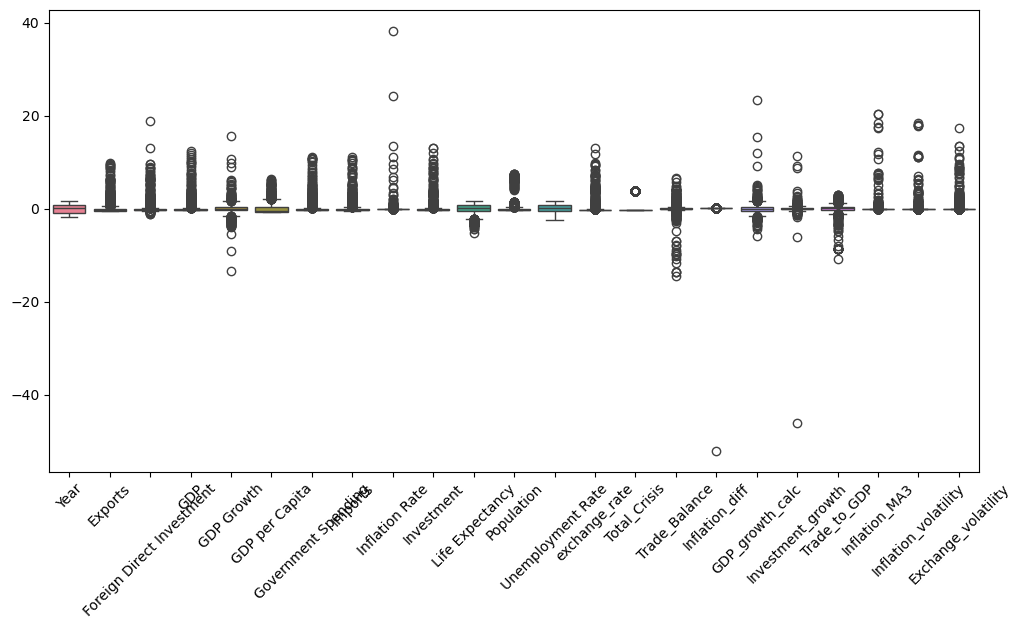

In [205]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_scaled[selected_features_var])

plt.xticks(rotation=45)
plt.show()

# 2 correlation

redundant feature 

In [206]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def correlation_filter(df, threshold=0.95, plot=True):
    
    
    df_numeric = df.select_dtypes(include=[np.number])
    
    corr_matrix = df_numeric.corr().abs()
    
    if plot:
        plt.figure(figsize=(14, 10))
        sns.heatmap(
            corr_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
        )
        plt.title("Feature Correlation Heatmap")
        plt.show()
    
    # Upper triangle
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    

    to_drop = [
        column for column in upper.columns 
        if any(upper[column] > threshold)
    ]

    print("Dropped features:", to_drop)


    return df.drop(columns=to_drop), to_drop

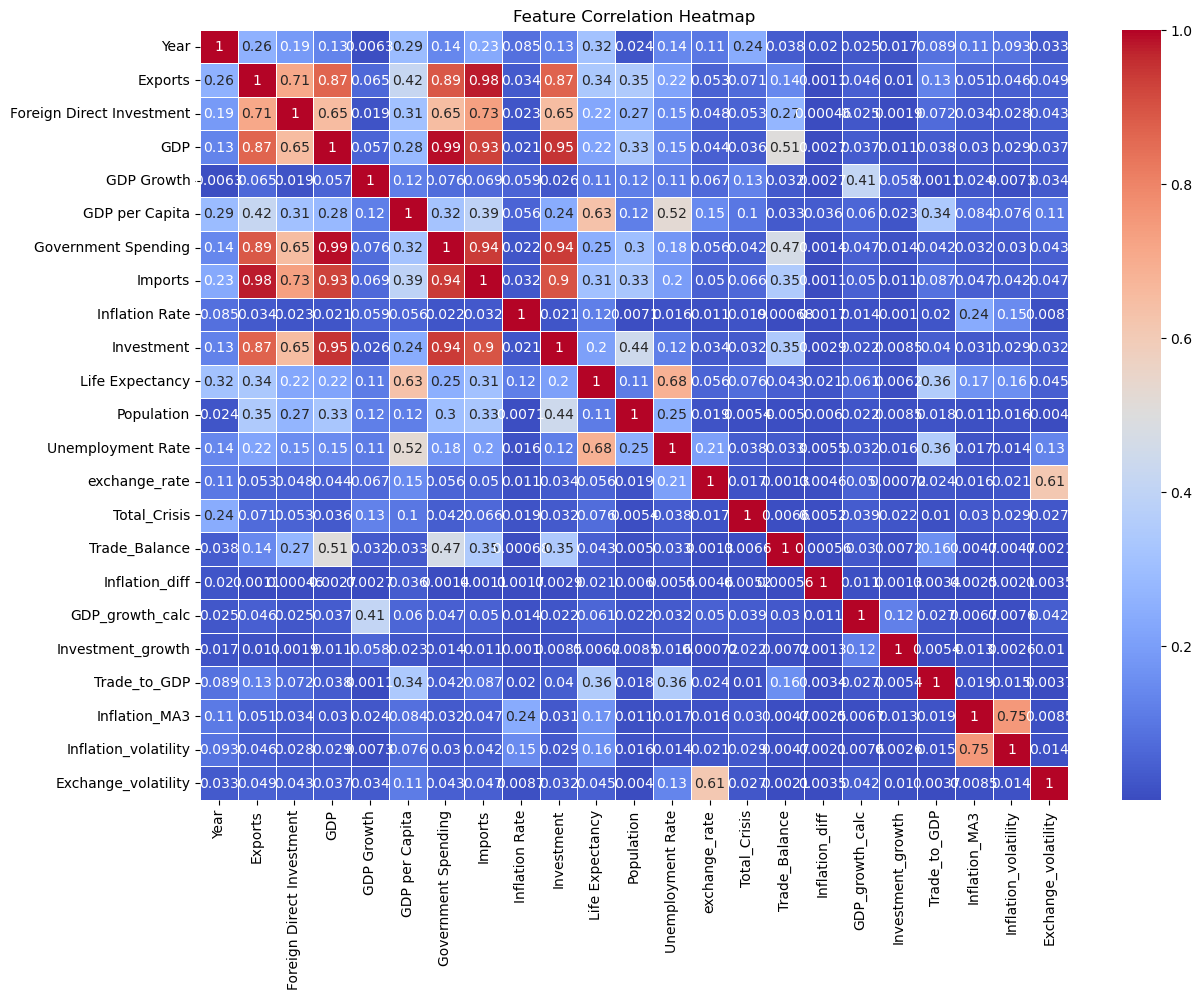

Dropped features: ['Government Spending', 'Imports', 'Investment']


In [207]:
features_df = train_scaled[selected_features_var]

filtered_df, dropped = correlation_filter(
    features_df,
    threshold=0.9
)

# 3 model

what is the highest effect on the target?

In [208]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

target=['GDP']
model.fit(filtered_df, train_scaled[target])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [209]:
importance = pd.DataFrame({
    'feature': filtered_df.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                      feature  importance
3                         GDP    0.769595
16               Trade_to_GDP    0.169528
7             Life Expectancy    0.021115
5              GDP per Capita    0.020182
1                     Exports    0.005105
8                  Population    0.004017
2   Foreign Direct Investment    0.002131
10              exchange_rate    0.002050
4                  GDP Growth    0.001915
15          Investment_growth    0.001598
14            GDP_growth_calc    0.000608
17              Inflation_MA3    0.000442
19        Exchange_volatility    0.000435
18       Inflation_volatility    0.000307
12              Trade_Balance    0.000286
0                        Year    0.000236
9           Unemployment Rate    0.000207
13             Inflation_diff    0.000138
6              Inflation Rate    0.000074
11               Total_Crisis    0.000029


final selected feature

In [210]:
selected_features = importance[
    importance['importance'] > 0.01
]['feature'].tolist()



`time series preparing data`

In [211]:
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

In [212]:
train_=train_scaled[selected_features]
test_=test_scaled[selected_features]
val_=val_scaled[selected_features]



train_=pd.concat([train_scaled,train["Country"]], axis=1)
val_=pd.concat([val_scaled,val["Country"]],axis=1)
test_=pd.concat([test_scaled,test["Country"]], axis=1)

In [213]:
le = LabelEncoder()

train_['country_id'] = le.fit_transform(train_['Country'])
val_['country_id']   = le.transform(val_['Country'])
test_['country_id']  = le.transform(test_['Country'])

train_ =train_ .drop(columns=['Country'])
val_ =val_ .drop(columns=['Country'])
test_ =test_ .drop(columns=['Country'])


target_cols = ['GDP']
selected_features = train_.columns


num_countries = len(le.classes_)

In [214]:
def prepare_multi_output_ds(df, feature_cols, target_cols, window_size=5, batch_size=32):
    
    df = df.sort_values(['country_id', 'Year']).reset_index(drop=True)
    
    ds = tf.data.Dataset.from_tensor_slices((
        df['country_id'].values.astype('int32'),
        df[feature_cols].values.astype('float32'),
        df[target_cols].values.astype('float32')
    ))
    print(target_cols)

    ds = ds.window(window_size, shift=1, drop_remainder=True)
    
    ds = ds.flat_map(
        lambda c, f, t: tf.data.Dataset.zip((c, f, t)).batch(window_size)
    )

    ds = ds.filter(lambda c, f, t: tf.equal(c[0], c[-1]))

    def map_fn(c, f, t):
        return {"country_in": c[0], "ts_in": f}, t[-1]

    ds = ds.map(map_fn)

    return ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [215]:
window = 5

train_ds = prepare_multi_output_ds(train_, selected_features, target_cols, window)
val_ds   = prepare_multi_output_ds(val_, selected_features, target_cols, window)

['GDP']
['GDP']


In [216]:
def build_multi_target_lstm(num_countries, num_features, num_targets, window_size=5):
    

    country_in = layers.Input(shape=(1,), name="country_in")
    emb = layers.Embedding(num_countries, 8)(country_in)
    emb = layers.Reshape((8,))(emb)
    emb_seq = layers.RepeatVector(window_size)(emb)

    ts_in = layers.Input(shape=(window_size, num_features), name="ts_in")

    merged = layers.Concatenate()([ts_in, emb_seq])

    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(merged)
    x = layers.LSTM(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='relu')(x)

    output = layers.Dense(num_targets, name="output")(x)

    model = Model(inputs=[country_in, ts_in], outputs=output)

    def r2_score(y_true, y_pred):
        ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
        ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
        return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae', r2_score]
    )

    return model

In [217]:
model = build_multi_target_lstm(
    num_countries=num_countries,
    num_features=len(selected_features),
    num_targets=len(target_cols),
    window_size=window
)

model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ country_in          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 1, 8)      │        768 │ country_in[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 8)         │          0 │ embedding_12[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ts_in (InputLayer)  │ (None, 5, 24)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_12    │ (None, 5, 8)      │          0 │ reshape_12[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 5, 32)     │          0 │ ts_in[0][0],      │
│ (Concatenate)       │                   │            │ repeat_vector_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_24 (LSTM)      │ (None, 5, 64)     │     24,832 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 32)        │     12,416 │ lstm_24[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ lstm_25[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      1,056 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,233 (153.25 KB)

 Trainable params: 39,169 (153.00 KB)

 Non-trainable params: 64 (256.00 B)

In [218]:
train_ds
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
     72/Unknown 5s 6ms/step - loss: 1.0150 - mae: 0.5699 - r2_score: -1.6405

c:\Users\Omar\anaconda3\envs\DL_Torch\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.2349 - mae: 0.5252 - r2_score: -1.0991
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7378 - mae: 0.3726 - r2_score: -0.4543
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6110 - mae: 0.3187 - r2_score: -0.1508
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3702 - mae: 0.2892 - r2_score: 0.2402
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3271 - mae: 0.2789 - r2_score: 0.2094
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2774 - mae: 0.2502 - r2_score: -0.0032
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2641 - mae: 0.2451 - r2_score: 0.3340
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1858 - mae: 0.2242 - r2_score: 0.3396
Epoch 9/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1297 - mae: 0.2096 - r2_score: 0.4288
Epoch 10/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1826 - mae: 0.2130 - r2_score: 0.4884
Epoch 11/30
73/73 ━━━━━━━

<Axes: xlabel='GDP', ylabel='Investment'>

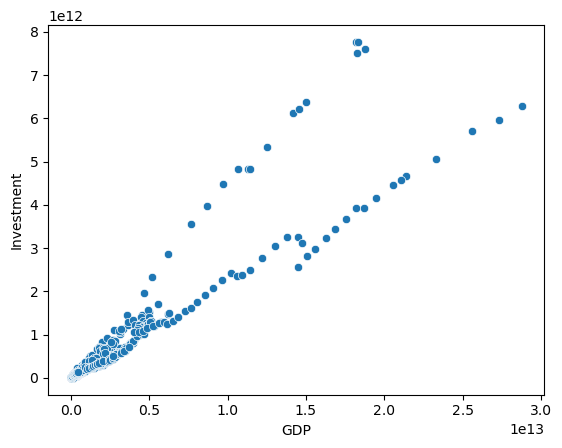

In [186]:
sns.scatterplot(x=df["GDP"], y=df["Investment"])

In [118]:
def feature_info(df):
    info = pd.DataFrame()

    info["dtype"] = df.dtypes
    info["missing"] = df.isnull().sum()
    info["missing_%"] = (df.isnull().sum() / len(df)) * 100
    info["n_unique"] = df.nunique()
    info["mean"] = df.mean(numeric_only=True)
    info["std"] = df.std(numeric_only=True)
    info["min"] = df.min(numeric_only=True)
    info["max"] = df.max(numeric_only=True)

    return info.sort_values("missing_%", ascending=False)

In [ ]:
feature_info(train_)

,dtype,missing,missing_%,n_unique,mean,std,min,max
Year,float64,0,0.0,31,3.646206e-15,1.000184,-1.772493,1.612365
Exports,float64,0,0.0,2627,-1.019918e-16,1.000184,-0.456324,9.827335
Foreign Direct Investment,float64,0,0.0,2653,-2.615174e-17,1.000184,-1.069441,18.852654
GDP,float64,0,0.0,2692,5.230348e-18,1.000184,-0.315679,12.471200
GDP Growth,float64,0,0.0,2717,1.046070e-17,1.000184,-13.412961,15.585075
GDP per Capita,float64,0,0.0,2692,2.144443e-16,1.000184,-0.768954,6.254218
Government Spending,float64,0,0.0,2616,4.707313e-17,1.000184,-0.332388,11.045348
Imports,float64,0,0.0,2627,-4.707313e-17,1.000184,-0.424753,10.986761
Inflation Rate,float64,0,0.0,2551,2.615174e-18,1.000184,-0.144928,38.222896
Investment,float64,0,0.0,2631,-4.445796e-17,1.000184,-0.313034,13.034328


In [ ]:
for col in train_.columns:
    sns.histplot(train_[col], kde=True)

KeyboardInterrupt: 